# Plotting the shedding fragmentomics data

## Set up

In [79]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu

In [53]:
OUTPUT_DIR = "/SAN/colcc/tracerx_personalis_pipeline/hannah/01.personalis/01.shedding/00.fragmentomics"

In [54]:
files = glob.glob(os.path.join(OUTPUT_DIR, "*_per_mut_fragmentomics.tsv"))
print(f"Found {len(files)} files")

Found 14 files


In [55]:
all_mutations = pd.concat([pd.read_csv(f, sep="\t") for f in files])
print(all_mutations.shape)
print(all_mutations.head())

(1932, 19)
    cruk_id tracerx_id            sample  chrom       pos ref alt  \
0  CRUK0080     LTX063  LTX063_5_26_2015  chr10  74101108   G   T   
1  CRUK0080     LTX063  LTX063_5_26_2015  chr11  10803498   T   C   
2  CRUK0080     LTX063  LTX063_5_26_2015  chr11   1256706   G   A   
3  CRUK0080     LTX063  LTX063_5_26_2015  chr11  64318425   C   A   
4  CRUK0080     LTX063  LTX063_5_26_2015  chr11    824292   G   T   

   ccf_z_score ccf_z_score_group  nb_wt  nb_mut  median_frag_length_wt  \
0    -1.105341               low   4615       4                  165.0   
1     0.704948              high   4590       3                  163.0   
2    -0.095126               low   4835       2                  167.0   
3    -2.013316               low   1194       3                  156.0   
4    -0.303560               low   3018       4                  162.0   

   median_frag_length_mut  median_distance_left_wt  median_distance_left_mut  \
0                   153.5                     80.

## Reshape data for plotting

In [56]:
# Reformat for plotting
frag_length_long = pd.melt(
    all_mutations,
    id_vars=["cruk_id", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)

print(frag_length_long.shape)
print(frag_length_long.head())

(3864, 9)
    cruk_id  chrom       pos ref alt  ccf_z_score ccf_z_score_group  \
0  CRUK0080  chr10  74101108   G   T    -1.105341               low   
1  CRUK0080  chr11  10803498   T   C     0.704948              high   
2  CRUK0080  chr11   1256706   G   A    -0.095126               low   
3  CRUK0080  chr11  64318425   C   A    -2.013316               low   
4  CRUK0080  chr11    824292   G   T    -0.303560               low   

           fragment_type  median_frag_length  
0  median_frag_length_wt               165.0  
1  median_frag_length_wt               163.0  
2  median_frag_length_wt               167.0  
3  median_frag_length_wt               156.0  
4  median_frag_length_wt               162.0  


# Deduplication

In [58]:
all_mutations_dedup = all_mutations.drop_duplicates(subset=["cruk_id", "chrom", "pos", "ref", "alt"]).copy()
all_mutations_dedup["delta_frag_length"] = all_mutations_dedup["median_frag_length_mut"] - all_mutations_dedup["median_frag_length_wt"]
print(all_mutations_dedup.shape)

(872, 20)


In [59]:
print(all_mutations_dedup.head())

    cruk_id tracerx_id            sample  chrom       pos ref alt  \
0  CRUK0080     LTX063  LTX063_5_26_2015  chr10  74101108   G   T   
1  CRUK0080     LTX063  LTX063_5_26_2015  chr11  10803498   T   C   
2  CRUK0080     LTX063  LTX063_5_26_2015  chr11   1256706   G   A   
3  CRUK0080     LTX063  LTX063_5_26_2015  chr11  64318425   C   A   
4  CRUK0080     LTX063  LTX063_5_26_2015  chr11    824292   G   T   

   ccf_z_score ccf_z_score_group  nb_wt  nb_mut  median_frag_length_wt  \
0    -1.105341               low   4615       4                  165.0   
1     0.704948              high   4590       3                  163.0   
2    -0.095126               low   4835       2                  167.0   
3    -2.013316               low   1194       3                  156.0   
4    -0.303560               low   3018       4                  162.0   

   median_frag_length_mut  median_distance_left_wt  median_distance_left_mut  \
0                   153.5                     80.0          

## Fragment lengths

In [60]:
frag_length_long = pd.melt(
    all_mutations_dedup,
    id_vars=["cruk_id", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)

# Clean up fragment_type labels
frag_length_long["fragment_type"] = frag_length_long["fragment_type"].map({
    "median_frag_length_wt": "WT",
    "median_frag_length_mut": "Mutant"
})

print(frag_length_long.shape)
print(frag_length_long["fragment_type"].value_counts())

(1744, 9)
fragment_type
WT        872
Mutant    872
Name: count, dtype: int64


In [61]:
frag_length_long

,cruk_id,chrom,pos,ref,alt,ccf_z_score,ccf_z_score_group,fragment_type,median_frag_length
0,CRUK0080,chr10,74101108,G,T,-1.105341,low,WT,165.0
1,CRUK0080,chr11,10803498,T,C,0.704948,high,WT,163.0
2,CRUK0080,chr11,1256706,G,A,-0.095126,low,WT,167.0
3,CRUK0080,chr11,64318425,C,A,-2.013316,low,WT,156.0
4,CRUK0080,chr11,824292,G,T,-0.303560,low,WT,162.0
...,...,...,...,...,...,...,...,...,...
1739,CRUK1161,chr8,18011393,T,G,-0.069768,low,Mutant,152.0
1740,CRUK1161,chr8,61499467,G,A,-0.596739,low,Mutant,150.0
1741,CRUK1161,chr9,115086004,C,G,-1.228944,low,Mutant,149.5
1742,CRUK1161,chr9,131039179,C,G,0.143048,high,Mutant,160.0


In [62]:
frag_length_long["group"] = frag_length_long["ccf_z_score_group"] + " " + frag_length_long["fragment_type"]
print(frag_length_long["group"].value_counts())

group
low WT         450
low Mutant     450
high WT        422
high Mutant    422
Name: count, dtype: int64


In [63]:
frag_length_long

,cruk_id,chrom,pos,ref,alt,ccf_z_score,ccf_z_score_group,fragment_type,median_frag_length,group
0,CRUK0080,chr10,74101108,G,T,-1.105341,low,WT,165.0,low WT
1,CRUK0080,chr11,10803498,T,C,0.704948,high,WT,163.0,high WT
2,CRUK0080,chr11,1256706,G,A,-0.095126,low,WT,167.0,low WT
3,CRUK0080,chr11,64318425,C,A,-2.013316,low,WT,156.0,low WT
4,CRUK0080,chr11,824292,G,T,-0.303560,low,WT,162.0,low WT
...,...,...,...,...,...,...,...,...,...,...
1739,CRUK1161,chr8,18011393,T,G,-0.069768,low,Mutant,152.0,low Mutant
1740,CRUK1161,chr8,61499467,G,A,-0.596739,low,Mutant,150.0,low Mutant
1741,CRUK1161,chr9,115086004,C,G,-1.228944,low,Mutant,149.5,low Mutant
1742,CRUK1161,chr9,131039179,C,G,0.143048,high,Mutant,160.0,high Mutant


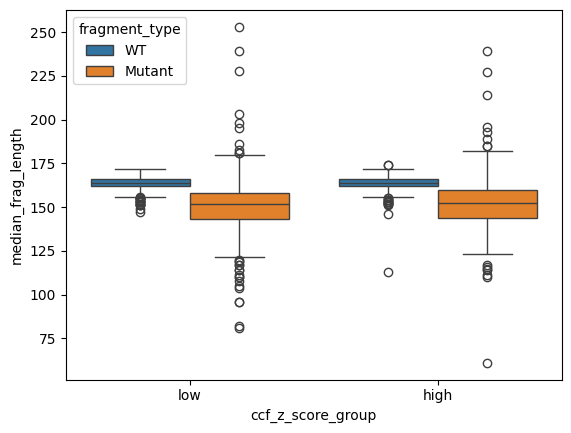

In [64]:
sns.boxplot(
    data=frag_length_long,
    x="ccf_z_score_group",
    y="median_frag_length",
    hue="fragment_type"
)
plt.show()

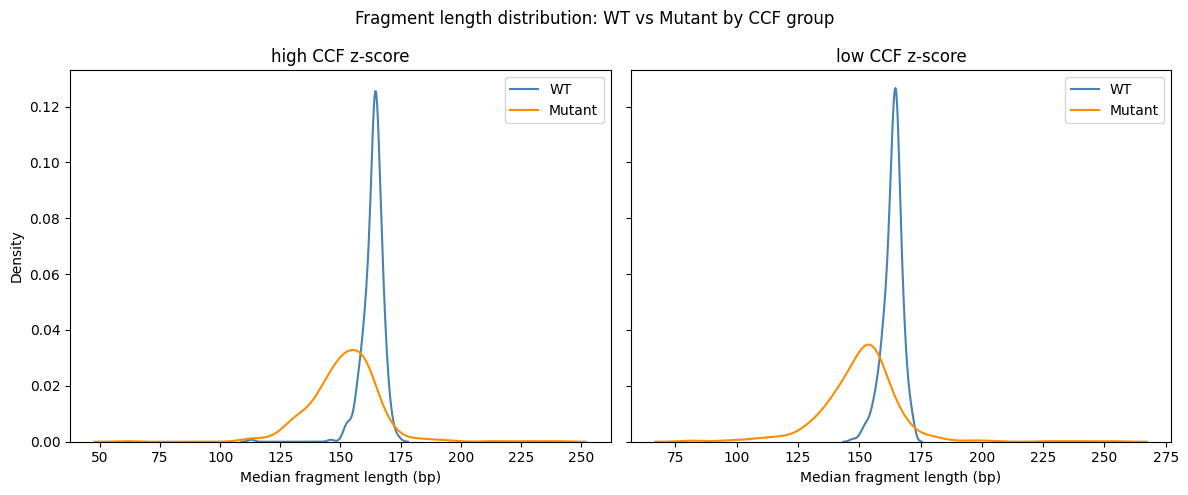

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, group in zip(axes, ["high", "low"]):
    for ftype, color in zip(["WT", "Mutant"], ["steelblue", "darkorange"]):
        subset = frag_length_long[
            (frag_length_long["ccf_z_score_group"] == group) &
            (frag_length_long["fragment_type"] == ftype)
        ]
        sns.kdeplot(subset["median_frag_length"], label=ftype, color=color, ax=ax)
    ax.set_title(f"{group} CCF z-score")
    ax.set_xlabel("Median fragment length (bp)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Fragment length distribution: WT vs Mutant by CCF group")
plt.tight_layout()
plt.show()

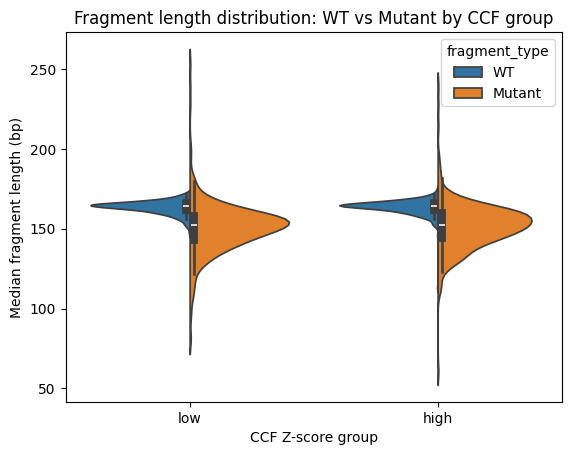

In [66]:
sns.violinplot(
    data=frag_length_long,
    x="ccf_z_score_group",
    y="median_frag_length",
    hue="fragment_type",
    split=True
)
plt.xlabel("CCF Z-score group")
plt.ylabel("Median fragment length (bp)")
plt.title("Fragment length distribution: WT vs Mutant by CCF group")
plt.show()

In [67]:
# Compute difference between differences in fragment length
all_mutations_dedup["delta_frag_length"] = all_mutations_dedup["median_frag_length_mut"] - all_mutations_dedup["median_frag_length_wt"]

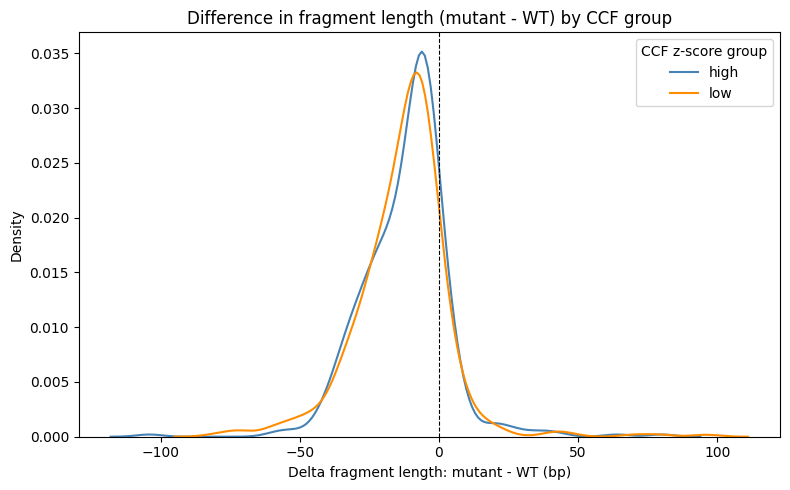

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_frag_length"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta fragment length: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in fragment length (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

In [69]:
high_delta = all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["delta_frag_length"].dropna()
low_delta = all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["delta_frag_length"].dropna()

stat, p = stats.mannwhitneyu(high_delta, low_delta, alternative="two-sided")
print(f"Mann-Whitney U: stat={stat:.1f}, p={p:.4f}")
print(f"Median delta high: {high_delta.median():.2f} bp")
print(f"Median delta low: {low_delta.median():.2f} bp")

Mann-Whitney U: stat=99642.5, p=0.2067
Median delta high: -9.00 bp
Median delta low: -11.00 bp


In [70]:
# Continuous correlation (Spearman)
spearmanr(all_mutations_dedup["ccf_z_score"].dropna(), all_mutations_dedup["delta_frag_length"].dropna())

SignificanceResult(statistic=0.020379251514581847, pvalue=0.5478458017343142)

## Distances

In [71]:
all_mutations_dedup["delta_min_distance"] = all_mutations_dedup["median_min_distance_mut"] - all_mutations_dedup["median_min_distance_wt"]

In [72]:
spearmanr(all_mutations_dedup["ccf_z_score"].dropna(), all_mutations_dedup["delta_min_distance"].dropna())

SignificanceResult(statistic=0.024545529281565687, pvalue=0.4691331779715876)

In [73]:
print(all_mutations_dedup["delta_min_distance"].describe())
print(all_mutations_dedup["delta_min_distance"].median())

count    872.000000
mean      -5.571101
std       14.717492
min      -51.000000
25%      -14.000000
50%       -4.000000
75%        3.000000
max       70.000000
Name: delta_min_distance, dtype: float64
-4.0


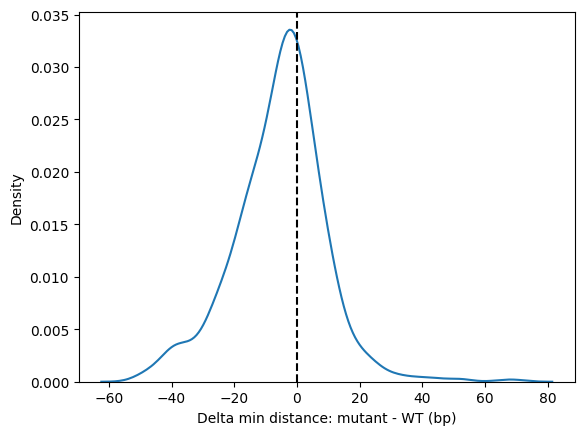

In [74]:
sns.kdeplot(all_mutations_dedup["delta_min_distance"].dropna())
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Delta min distance: mutant - WT (bp)")
plt.show()

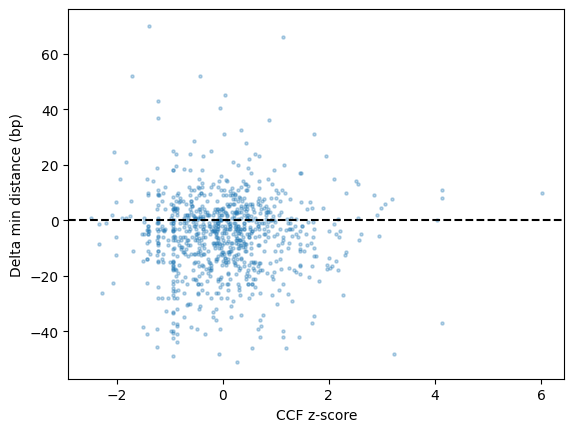

In [75]:
plt.scatter(all_mutations_dedup["ccf_z_score"], all_mutations_dedup["delta_min_distance"], alpha=0.3, s=5)
plt.xlabel("CCF z-score")
plt.ylabel("Delta min distance (bp)")
plt.axhline(0, color="black", linestyle="--")
plt.show()

# Without deduplication

In [ ]:
# Compute deltas
all_mutations["delta_frag_length"] = all_mutations["median_frag_length_mut"] - all_mutations["median_frag_length_wt"]
all_mutations["delta_min_distance"] = all_mutations["median_min_distance_mut"] - all_mutations["median_min_distance_wt"]

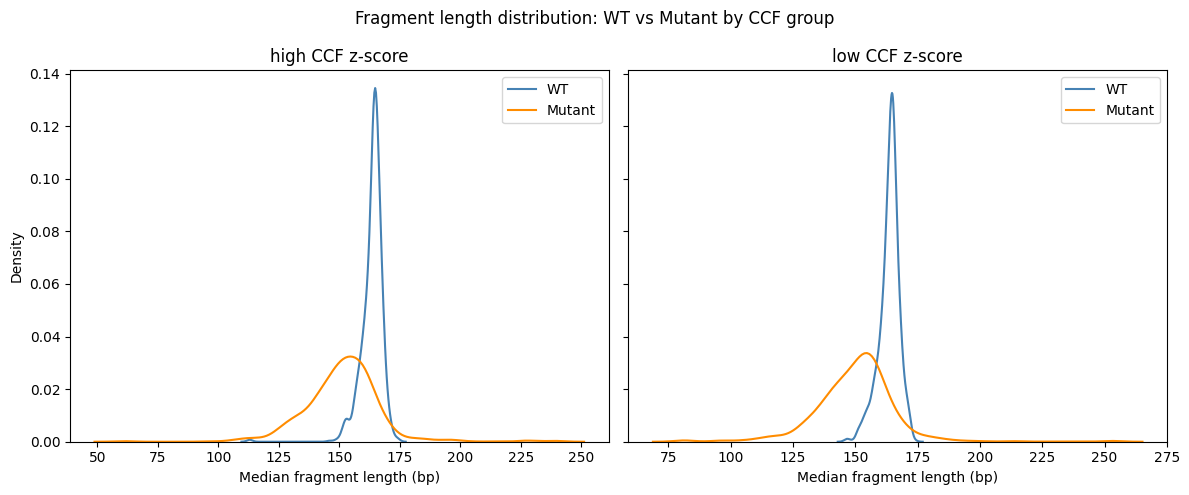

In [77]:
# Fragment length KDE by CCF group
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

frag_length_long = pd.melt(
    all_mutations,
    id_vars=["cruk_id", "sample", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)
frag_length_long["fragment_type"] = frag_length_long["fragment_type"].map({
    "median_frag_length_wt": "WT",
    "median_frag_length_mut": "Mutant"
})

for ax, group in zip(axes, ["high", "low"]):
    for ftype, color in zip(["WT", "Mutant"], ["steelblue", "darkorange"]):
        subset = frag_length_long[
            (frag_length_long["ccf_z_score_group"] == group) &
            (frag_length_long["fragment_type"] == ftype)
        ]
        sns.kdeplot(subset["median_frag_length"], label=ftype, color=color, ax=ax)
    ax.set_title(f"{group} CCF z-score")
    ax.set_xlabel("Median fragment length (bp)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Fragment length distribution: WT vs Mutant by CCF group")
plt.tight_layout()
plt.show()

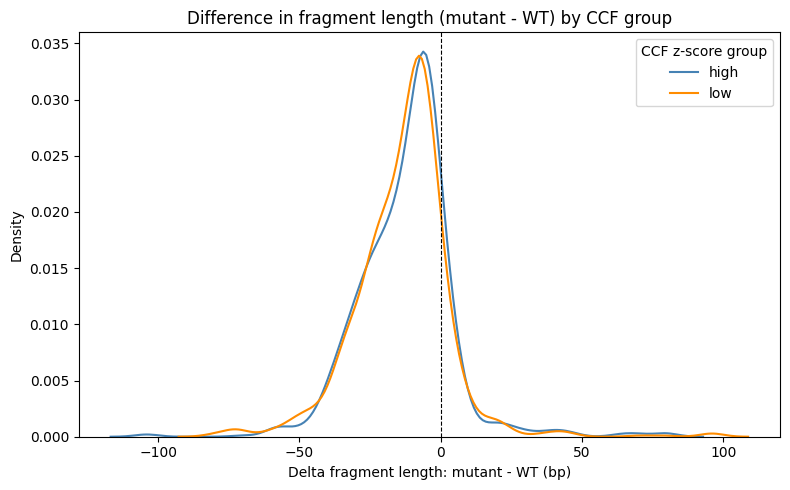

Mann-Whitney U: stat=488228.5, p=0.0728
Median delta high: -10.00 bp
Median delta low: -11.00 bp
SignificanceResult(statistic=0.02176210994400314, pvalue=0.33905339697976555)


In [80]:
# Delta fragment length KDE and stats
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations[all_mutations["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_frag_length"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta fragment length: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in fragment length (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

high_delta = all_mutations[all_mutations["ccf_z_score_group"] == "high"]["delta_frag_length"].dropna()
low_delta  = all_mutations[all_mutations["ccf_z_score_group"] == "low"]["delta_frag_length"].dropna()
stat, p = mannwhitneyu(high_delta, low_delta, alternative="two-sided")
print(f"Mann-Whitney U: stat={stat:.1f}, p={p:.4f}")
print(f"Median delta high: {high_delta.median():.2f} bp")
print(f"Median delta low: {low_delta.median():.2f} bp")
print(spearmanr(all_mutations["ccf_z_score"].dropna(), all_mutations["delta_frag_length"].dropna()))

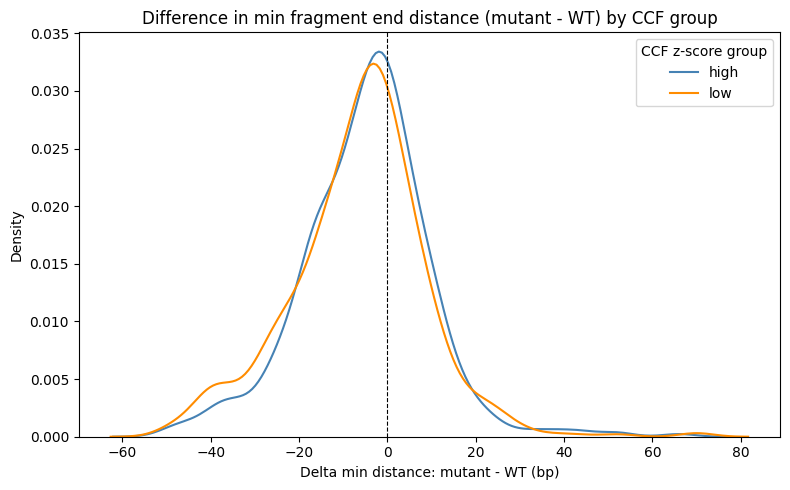

count    1932.000000
mean       -5.781832
std        15.020438
min       -51.000000
25%       -14.500000
50%        -4.500000
75%         3.000000
max        70.000000
Name: delta_min_distance, dtype: float64
SignificanceResult(statistic=0.032988729320973624, pvalue=0.14720919487169115)


In [85]:
# Delta min distance KDE and stats
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations[all_mutations["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_min_distance"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta min distance: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in min fragment end distance (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

print(all_mutations["delta_min_distance"].describe())
print(spearmanr(all_mutations["ccf_z_score"].dropna(), all_mutations["delta_min_distance"].dropna()))

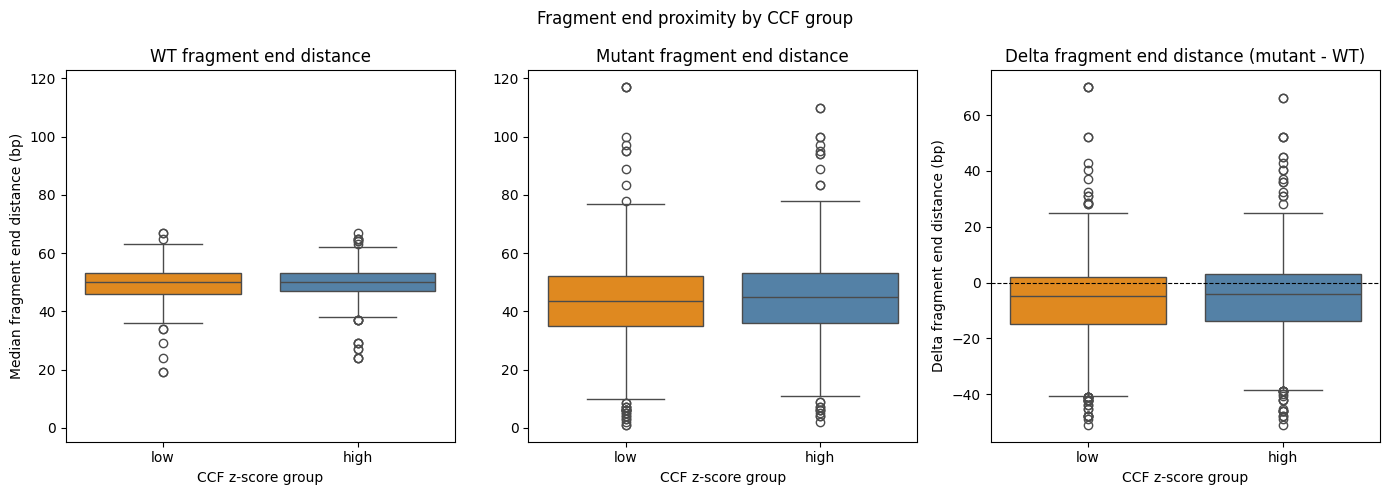

In [88]:
# Fragment end proximity boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="median_min_distance_wt",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[0])
axes[0].set_title("WT fragment end distance")
axes[0].set_xlabel("CCF z-score group")
axes[0].set_ylabel("Median fragment end distance (bp)")

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="median_min_distance_mut",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[1])
axes[1].set_title("Mutant fragment end distance")
axes[1].set_xlabel("CCF z-score group")
axes[1].set_ylabel("")

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="delta_min_distance",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[2])
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Delta fragment end distance (mutant - WT)")
axes[2].set_xlabel("CCF z-score group")
axes[2].set_ylabel("Delta fragment end distance (bp)")

# Share y axis between first two panels
ymin = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(ymin, ymax)
axes[1].set_ylim(ymin, ymax)

plt.suptitle("Fragment end proximity by CCF group")
plt.tight_layout()
plt.show()

/tmp/ipykernel_15134/1290104699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


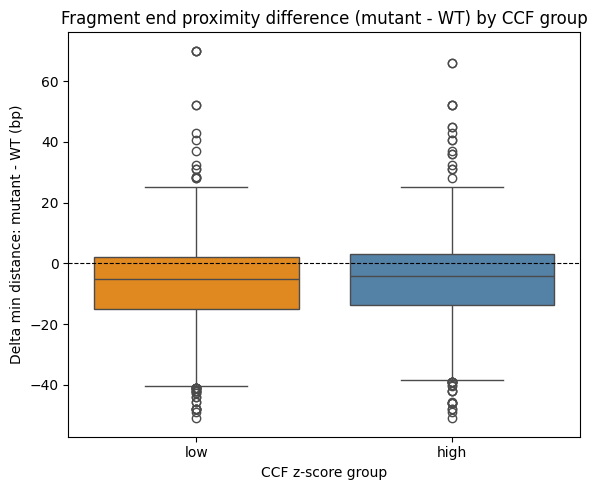

In [83]:
# Box plot showing delta min distance by CCF group
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=all_mutations,
    x="ccf_z_score_group",
    y="delta_min_distance",
    order=["low", "high"],
    palette=["darkorange", "steelblue"],
    ax=ax
)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("CCF z-score group")
ax.set_ylabel("Delta min distance: mutant - WT (bp)")
ax.set_title("Fragment end proximity difference (mutant - WT) by CCF group")
plt.tight_layout()
plt.show()

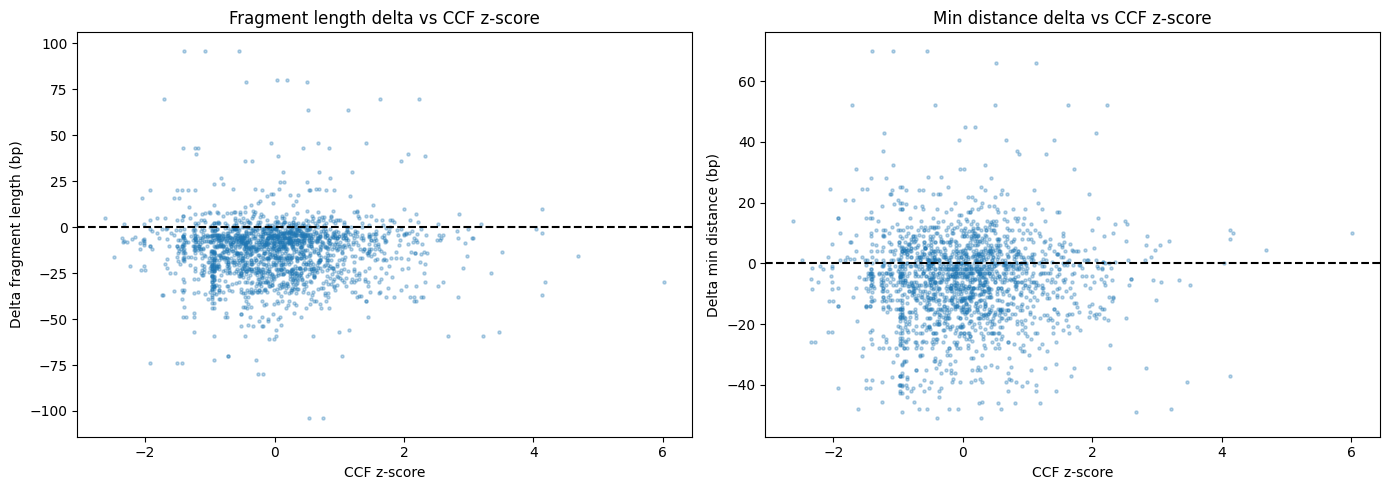

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_mutations["ccf_z_score"], all_mutations["delta_frag_length"], alpha=0.3, s=5)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("CCF z-score")
axes[0].set_ylabel("Delta fragment length (bp)")
axes[0].set_title("Fragment length delta vs CCF z-score")

axes[1].scatter(all_mutations["ccf_z_score"], all_mutations["delta_min_distance"], alpha=0.3, s=5)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("CCF z-score")
axes[1].set_ylabel("Delta min distance (bp)")
axes[1].set_title("Min distance delta vs CCF z-score")

plt.tight_layout()
plt.show()